100%|██████████| 170M/170M [00:17<00:00, 9.70MB/s]


Epoch 1, Loss: 1.4459
Epoch 2, Loss: 1.1117
Epoch 3, Loss: 0.9728
Epoch 4, Loss: 0.8715
Epoch 5, Loss: 0.7943
Epoch 6, Loss: 0.7228
Epoch 7, Loss: 0.6605
Epoch 8, Loss: 0.5987
Epoch 9, Loss: 0.5430
Epoch 10, Loss: 0.4916
Accuracy on test data: 68.90%


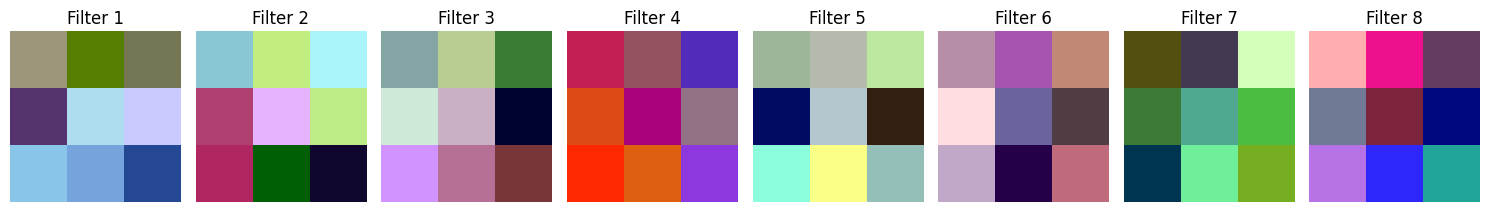

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Step 1: Load and preprocess CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False)

classes = trainset.classes

# Step 2: Define CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 32 * 8 * 8)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Step 3: Train CNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)

lossfn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = lossfn(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: "
          f"{running_loss / len(trainloader):.4f}")

# Step 4: Evaluate model
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy on test data: "
      f"{100 * correct / total:.2f}%")

# Step 5: Visualize learned filters
def visualize_filters(layer, n_filters=8):
    filters = layer.weight.data.cpu()

    fig, axs = plt.subplots(1, n_filters, figsize=(15, 4))

    for i in range(n_filters):
        f = filters[i]
        f = (f - f.min()) / (f.max() - f.min())

        axs[i].imshow(f.permute(1, 2, 0))
        axs[i].axis('off')
        axs[i].set_title(f'Filter {i+1}')

    plt.tight_layout()
    plt.show()

visualize_filters(model.conv1)